# Solutions 




# PART 1: Two-hidden layer neural network (forward pass computation)


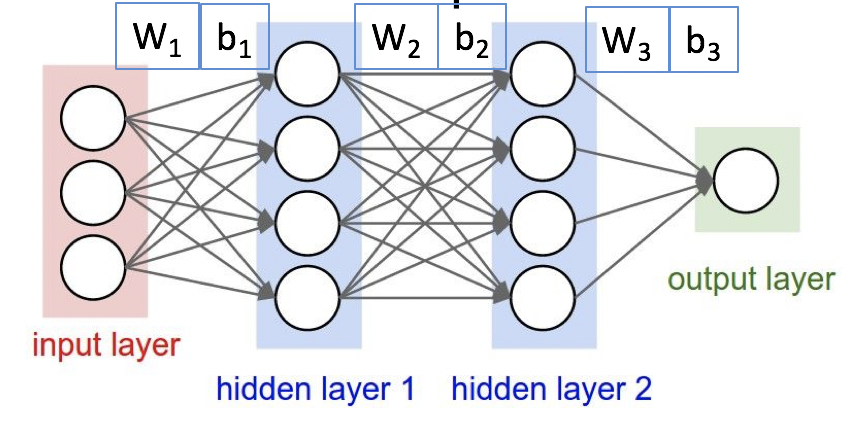

# **Task:**
Change the architecture to predict a 3-dimensional output, e.g. a weather forecast for the next three days. 








In [ ]:
import numpy as np
from numpy.random import randn
W1,W2,W3 = randn(4, 3), randn(4, 4), randn(3, 4) #initialisations of weights
b1,b2,b3 = randn(4,1), randn(4,1), randn(3,1)    #initialisations of biases

f = lambda x: 1.0/(1.0 + np.exp(-x))   #sigmoid activation function
x = randn(3,1) #random input vector of three numbers (3x1)
#print(x)
h1 = f(np.dot(W1,x)+b1)  #calculate first hidden layer activations (4x1)
h2 = f(np.dot(W2,h1) +b2) #calculate second hidden layer activations (4x1)
out = np.dot(W3,h2)+b3  #output neuron (1x1)    

print(out)

[[ 0.30954701]
 [-1.12222245]
 [-1.80590423]]




---



#PART 2: Training a neural network

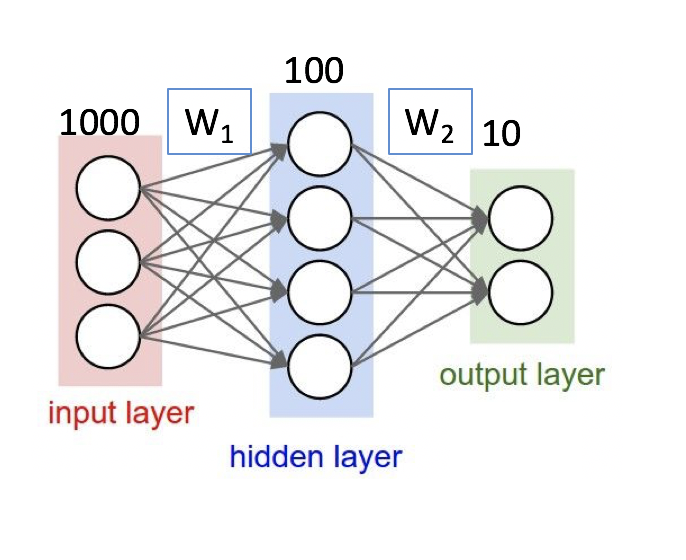

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn

Define the network

In [ ]:
N,D_in, H, D_out = 64, 1000, 100, 10
W1,W2 = randn(H, D_in), randn(D_out, H)
x,y = randn(D_in, N), randn(D_out,N)

Perform training using gradient descent algorithm

In [ ]:
plotloss=[]
for t in range(2000):
	h = 1 / (1 + np.exp(-np.dot(W1,x)))       
	y_pred = np.dot(W2,h)
	loss = np.square(y_pred - y).sum()
	#print(t,loss)
	plotloss.append(loss)
	
	grad_y_pred = 2.*(y_pred - y)
	grad_W2 = np.dot(grad_y_pred,h.T)
	grad_h = np.dot(W2.T,grad_y_pred)
	grad_W1 = np.dot(grad_h * h*(1-h),x.T)

	W1 -=1e-4 * grad_W1
	W2 -=1e-4 * grad_W2


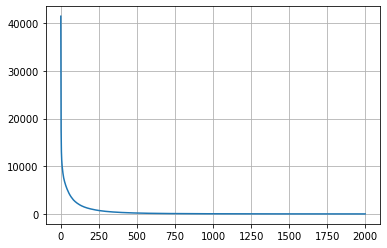

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(range(2000),np.array(plotloss))
plt.grid()
plt.show()

# **Task:**

1. Complete the statement: 

> `The gradient grad_W1, grad_W2 is taken w.r.t. the A) parameters in the previous layers, B) input data x, C) loss value, D) predictions in the output layer`

**Answer: C**

2. Verify the dimensions of the grad_W1, and grad_W2 variables. 
Do they match the dimensions of W1 and W2? what does the gradient tell us w.r.t. the objective function?

**Answer:** `grad_W1, and grad_W2 tell us how changes in W1, W2 influence the loss value, which is our oblective function.  `

3. Change the learning rate to `1e-2, 1e-1, 1.0`, and observe the behaviour of the gradients and the loss. Change the initialisation of the weights to be all `1.0`, and observe the behaviour of the gradients and the loss. 


**Answer:**

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: RuntimeWarning: overflow encountered in exp
  """
/usr/local/lib/python3.7/dist-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: RuntimeWarning: overflow encountered in square
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in multiply
  


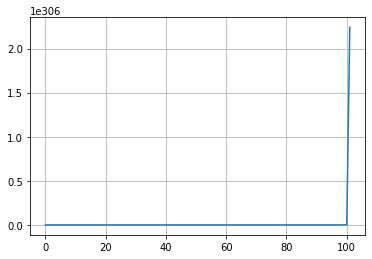

In [ ]:
W1,W2 = randn(H, D_in), randn(D_out, H)
#x,y = randn(D_in, N), randn(D_out,N)
plotloss=[]
for t in range(2000):
	h = 1 / (1 + np.exp(-np.dot(W1,x)))       
	y_pred = np.dot(W2,h)
	loss = np.square(y_pred - y).sum()
	#print(t,loss)
	plotloss.append(loss)
	
	grad_y_pred = 2.*(y_pred - y)
	grad_W2 = np.dot(grad_y_pred,h.T)
	grad_h = np.dot(W2.T,grad_y_pred)
	grad_W1 = np.dot(grad_h * h*(1-h),x.T)

	W1 -=1e-2 * grad_W1
	W2 -=1e-2 * grad_W2

plt.plot(range(2000),np.array(plotloss))
plt.grid()
plt.show()

The loss value have exploded - too high learning rate.

#PART 3: Training and testing a neural network on real data

Use the Wine Quality dataset [link text](http://archive.ics.uci.edu/ml/datasets/Wine+Quality) text to train and evaluate the model. Use only the red wine data. The goal is to find the quality score of some wine based on its attributes.

We will follow closely the previous example and use a single hidden layer, a sigmoid function at the hidden layer and a linear function at the output layer, followed by a squared error loss. The network will have 30 hidden neurons (i.e. H=30) and 1 output neuron (i.e. D_out=1).



First, download the winequality-red.csv file, load it, and divide the data into a training and test set using approximately 50% for training. Consider standardizing the data, by computing the mean and standard deviation for each feature dimension using the train set only, then subtracting the mean and dividing by the stdev for each feature and each sample. Append a 1 for each feature vector, which will correspond to the bias that our model learns. Set the number of hidden units to 30, the number of iterations to run to 1000, and the learning rate to 1e-4.


# **Task:** 
1. Evaluate your model on the test data. What is the performance?

2. Plot a loss curve to visualise the loss values changing over running time. Visualise the loss curve  on training data and on test data. Compare the performances. What do the plots tell us?

3. Experiment with three different values of the learning rate, and plot the loss curves per each of the values. Compare the behaviour and the final performances.



In [ ]:
#This code was written by V. Sharmanska. All rights reserved.
# Load in the data
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
import pandas as pd
data = pd.read_csv("winequality-red.csv", sep=";")

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from numpy.random import randn
from sklearn.preprocessing import StandardScaler
import pdb

Data = data.drop("quality", axis=1).to_numpy()  # type: ignore
Labels = np.reshape(data["quality"].to_numpy(), (-1, 1))  # type: ignore
Data = np.c_[Data, np.ones((Data.shape[0],1))]
num_features = Data.shape[1]
num_targets = 1

X_train, X_test = np.array_split(Data, 2)  # type: ignore
y_train, y_test = np.array_split(Labels, 2)  # type: ignore

feature_scaler = StandardScaler()
target_scaler = StandardScaler()
# Normalize the data using the first & second moments computed from the training set
X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)



These are the best results achieved using 1e-1 learning rate and 5K epochs. Note that MSE (mean squared error) has been used during training and evaluation. 

Train MSE loss 0.3155183170475279


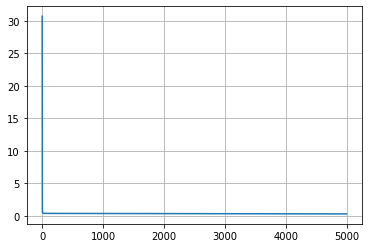

In [ ]:
N,D_in, H, D_out = 800, 12, 30, 1
W1,W2 = randn(H, D_in)*0.1, randn(D_out, H)*0.1

x=X_train.copy().T
y=y_train.copy().T
plotloss=[]
for t in range(5000):
	h = 1 / (1 + np.exp(-np.dot(W1,x)))       
	y_pred = np.dot(W2,h)
	loss = np.square(y_pred - y).sum()/N
	#print(t,loss)
	plotloss.append(loss)
	
	grad_y_pred = 2.*(y_pred - y)/N
	grad_W2 = np.dot(grad_y_pred,h.T)
	grad_h = np.dot(W2.T,grad_y_pred)
	grad_W1 = np.dot(grad_h * h*(1-h),x.T)

	W1 -=1e-1 * grad_W1
	W2 -=1e-1 * grad_W2

print('Train MSE loss', loss)
plt.plot(range(5000),np.array(plotloss))
plt.grid()
plt.show()

In [ ]:
#testing
x=X_test.copy().T
y=y_test.copy().T

h = 1 / (1 + np.exp(-np.dot(W1,x)))       
y_pred = np.dot(W2,h)
loss = np.mean(np.square(y_pred - y)) #same as np.square(y_pred - y).sum()/N_test
print('Test MSE loss',loss)

y_quality=y_pred.astype(int)
print('The model predictions are in this range: ',np.unique(y_quality))
print('The test labels are in this range: ', np.unique(y))
print('Accuracy %.2f%%'%(100*np.sum(y==y_quality)/len(y_test)))

Test MSE loss 0.4711369444821932
The model predictions are in this range:  [4 5 6 7]
The test labels are in this range:  [3 4 5 6 7 8]
Accuracy 49.81%
